In [1]:
import numpy as np                        # Μαθηματική/αριθμητική βιβλιοθήκη
import matplotlib.pyplot as plt           # Βιβλιοθήκη απεικονίσεων
from scipy.integrate import solve_ivp     # Έτοιμος αριθμητικός επιλύτης ΣΔΕ (ODE solver)
%matplotlib inline

## Άσκηση - Άμεση Επίλυση Διαφορικών Εξισώσεων με Έτοιμη Βιβλιοθήκη

Αν λύσατε και τις υπόλοιπες ασκήσεις του Κεφαλαίου, θα παρατηρήσατε ότι **εμείς** διακριτοποιήσαμε τη διαφορική εξίσωση: γράψαμε με το χέρι τη διακριτού χρόνου εξίσωση διαφορών (μέθοδος Euler) και υλοποιήσαμε την αναδρομή σε ένα `for` loop. Αυτό μας έδωσε πλήρη έλεγχο και εποπτεία, αλλά είδαμε επίσης ότι ο (εμπρόσθιος) Euler είναι σχετικά ανακριβής και απαιτεί μικρό $T_s$.

Όπως αναφέρθηκε ήδη στην άσκηση $\texttt{Ex-DifferentialEquations}$, η `Python` διαθέτει **έτοιμες συναρτήσεις** που λύνουν διαφορικές εξισώσεις. Εδώ θα χρησιμοποιήσουμε την `scipy.integrate.solve_ivp` για να λύσουμε **το ίδιο** σύστημα δεύτερης τάξης, **χωρίς να παράγουμε εμείς τη διακριτή εξίσωση διαφορών**.

**Σημαντική διευκρίνιση (για να μην υπάρχει παρανόηση):** και ο `solve_ivp` κάνει στο τέλος αριθμητική ολοκλήρωση σε διακριτά βήματα — δεν υπάρχει τρόπος ο υπολογιστής να αποθηκεύσει τη *συνεχή* μεταβλητή $t$. Η διαφορά είναι ότι:

1. **Δεν** παράγουμε εμείς την εξίσωση διαφορών: δίνουμε απλώς τη διαφορική εξίσωση σε μια ειδική μορφή, την $\dot{\mathbf{s}}=f(t,\mathbf{s})$.
2. Ο επιλύτης χρησιμοποιεί μεθόδους **υψηλότερης τάξης και προσαρμοστικού βήματος** (π.χ. `RK45`, δηλ. Runge–Kutta 4ης/5ης τάξης) που είναι πολύ πιο ακριβείς από τη μέθοδο του Euler και **επιλέγουν μόνες τους** το βήμα ολοκλήρωσης ανάλογα με το πόσο «γρήγορα» αλλάζει η λύση.

Δουλεύουμε με το **ίδιο** σύστημα δεύτερης τάξης με τις ασκήσεις στα υπόλοιπα notebooks:

$$ \frac{d^2 y}{dt^2} + 2\zeta\omega_n\frac{dy}{dt} + \omega_n^2 y = \omega_n^2 x(t), \qquad \omega_n=4,\ \zeta=0.25 $$

H `solve_ivp` λύνει συστήματα **πρώτης τάξης** της μορφής $\dot{\mathbf{s}} = f(t,\mathbf{s})$. Άρα πρέπει και πάλι να γράψουμε την εξίσωση δεύτερης τάξης ως σύστημα με μεταβλητές κατάστασης $\mathbf{s}=[y_1,y_2]^\top=[y,\dot y]^\top$:

\begin{align*}
    \dot y_1 &= y_2 \\
    \dot y_2 &= -\omega_n^2 y_1 - 2\zeta\omega_n y_2 + \omega_n^2 x(t)
\end{align*}

**Προσοχή στη διαφορά:** το να γράψουμε την εξίσωση σε μορφή πρώτης τάξης **δεν** είναι διακριτοποίηση - παραμένει συνεχούς χρόνου. Απλώς είναι η μορφή που «καταλαβαίνει» ο επιλύτης. Τη διακριτοποίηση (επιλογή βημάτων) την αναλαμβάνει εσωτερικά η `solve_ivp`.

Ορίζουμε τη συνάρτηση $f(t,\mathbf{s})$ που επιστρέφει το $\dot{\mathbf{s}}$. Επειδή η είσοδος $x(t)$ αλλάζει ανά σενάριο (μηδενικής εισόδου / μηδενικής κατάστασης), την περνάμε ως όρισμα.

In [2]:
# --- Παράμετροι συστήματος ---
wn    = 4.0                               # φυσική συχνότητα ω_n
zeta  = 0.25                              # συντελεστής απόσβεσης ζ
sigma = zeta*wn                           # ρυθμός απόσβεσης σ = ζω_n
wd    = wn*np.sqrt(1 - zeta**2)           # συχνότητα ω_d

def rhs(t, s, x_func):
    """Δεξί μέλος dot(s) = f(t, s) του συστήματος πρώτης τάξης.
       s = [y1, y2] = [y, y'].  Η x_func(t) είναι η είσοδος x(t)."""
    y1, y2 = s
    dy1 = y2
    dy2 = -wn**2 * y1 - 2*zeta*wn * y2 + wn**2 * x_func(t)
    return [dy1, dy2]

### Απόκριση μηδενικής εισόδου (ZIR) με `solve_ivp`

Θέτουμε $x(t)=0$ και αρχική κατάσταση $\mathbf{s}(0)=[y(0),\dot y(0)]=[1,0]$. Δίνουμε στον επιλύτη το χρονικό διάστημα `t_span=(0,5)` και ζητάμε την έξοδο σε άξονα `t_eval` (μόνο για την απεικόνιση - ο εσωτερικός επιλύτης χρησιμοποιεί δικά του, προσαρμοστικά βήματα).

In [8]:
t = np.linspace(0, 5, 500)                # άξονας για απεικόνιση

# Επίλυση: ΚΑΜΙΑ εξίσωση διαφορών - απλώς δίνουμε τη ΣΔΕ και τις αρχικές συνθήκες
sol_zir = solve_ivp(rhs, t_span=(0, 5), y0=[1.0, 0.0],
                    args=(lambda t: 0.0,),   # x(t) = 0  (zero-input)
                    method='RK45', t_eval=t, rtol=1e-8, atol=1e-10)

y_zir     = sol_zir.y[0]                   # η θέση y(t) = πρώτη μεταβλητή κατάστασης
y_zir_th  = np.exp(-sigma*t)*(1.0*np.cos(wd*t) + (0.0 + sigma*1.0)/wd*np.sin(wd*t))  # θεωρία

print('Αποτέλεσμα:', sol_zir.message)

Αποτέλεσμα: The solver successfully reached the end of the integration interval.


### Απόκριση μηδενικής κατάστασης (ZSR) με `solve_ivp`

Θέτουμε μηδενικές αρχικές συνθήκες $\mathbf{s}(0)=[0,0]$ και είσοδο ένα οποιοδήποτε σήμα. Ας πούμε ότι θέτουμε ως είσοδο το γνωστό μας $x(t)=u(t)$ (για $t\ge 0$, δηλ. `x_func = lambda t: 1.0`).

In [9]:
sol_zsr = solve_ivp(rhs, t_span=(0, 5), y0=[0.0, 0.0],
                    args=(lambda t: 1.0,),   # x(t) = u(t)  (zero-state)
                    method='RK45', t_eval=t, rtol=1e-8, atol=1e-10)

y_zsr     = sol_zsr.y[0]
y_zsr_th  = 1 - np.exp(-sigma*t)*(np.cos(wd*t) + (sigma/wd)*np.sin(wd*t))            # θεωρία

print('Αποτέλεσμα:', sol_zsr.message)

Αποτέλεσμα: The solver successfully reached the end of the integration interval.


#### Σύγκριση με τη μέθοδο του Euler

Για να δούμε το κέρδος σε ακρίβεια, υπολογίζουμε και την προσέγγιση της **μεθόδου Euler** με $T_s=0.01$ s για το σενάριο ZSR, και τη συγκρίνουμε με τη `solve_ivp` και με τη θεωρία.

In [11]:
Ts = 0.01
t_e = np.arange(0, 5, Ts)
xe  = np.ones(len(t_e))
y1 = np.zeros(len(t_e)); y2 = np.zeros(len(t_e))
for n in range(len(t_e)-1):               # μέθοδος Euler (χειροκίνητη διακριτοποίηση)
    y1[n+1] = y1[n] + Ts*y2[n]
    y2[n+1] = y2[n] + Ts*(-wn**2*y1[n] - 2*zeta*wn*y2[n] + wn**2*xe[n])
y_euler = y1

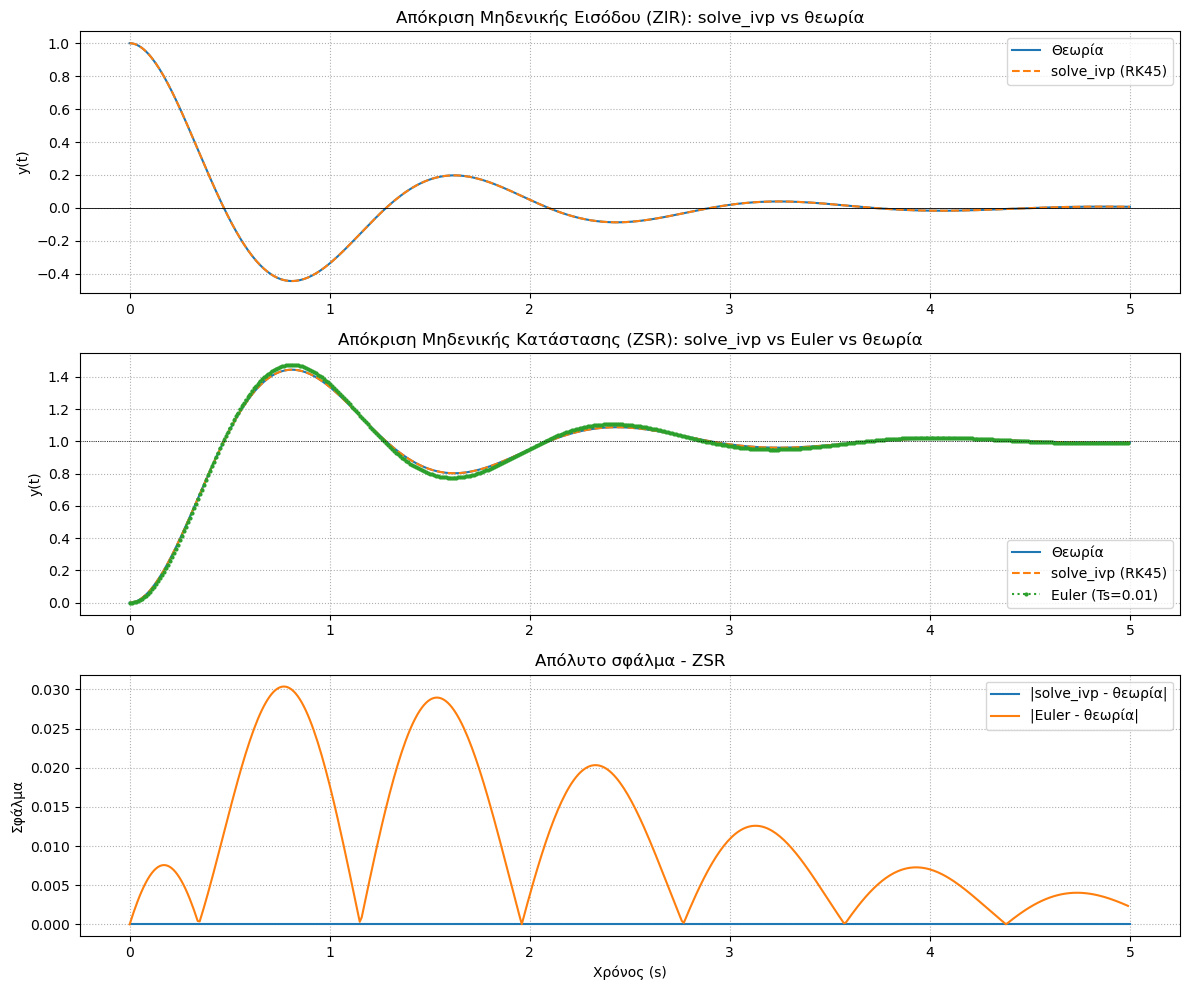

In [15]:
# --- Γραφήματα ---
plt.figure(figsize=(12, 10))

# (α) ZIR: solve_ivp vs θεωρία
plt.subplot(3, 1, 1)
plt.plot(t, y_zir_th, '-',  label='Θεωρία')
plt.plot(t, y_zir,    '--', label='solve_ivp (RK45)')
plt.axhline(0, color='k', linewidth=0.6)
plt.grid(linestyle=':'); plt.legend(loc='upper right')
plt.title('Απόκριση Μηδενικής Εισόδου (ZIR): solve_ivp vs θεωρία')
plt.ylabel('y(t)')

# (β) ZSR: solve_ivp vs Euler vs θεωρία
plt.subplot(3, 1, 2)
plt.plot(t,   y_zsr_th, '-',  label='Θεωρία')
plt.plot(t,   y_zsr,    '--', label='solve_ivp (RK45)')
plt.plot(t_e, y_euler,  ':o', markersize=2, label='Euler (Ts=0.01)')
plt.axhline(1, color='k', linewidth=0.6, linestyle=':')
plt.grid(linestyle=':'); plt.legend(loc='lower right')
plt.title('Απόκριση Μηδενικής Κατάστασης (ZSR): solve_ivp vs Euler vs θεωρία')
plt.ylabel('y(t)')

# (γ) Απόλυτα σφάλματα ως προς τη θεωρία (ZSR)
err_ivp   = np.abs(y_zsr - y_zsr_th)
y_euler_th = 1 - np.exp(-sigma*t_e)*(np.cos(wd*t_e) + (sigma/wd)*np.sin(wd*t_e))
err_euler = np.abs(y_euler - y_euler_th)
plt.subplot(3, 1, 3)
plt.plot(t,   err_ivp,   label='|solve_ivp - θεωρία|')
plt.plot(t_e, err_euler, label='|Euler - θεωρία|')
plt.grid(linestyle=':', which='both'); plt.legend(loc='upper right')
plt.title('Απόλυτο σφάλμα - ZSR')
plt.xlabel('Χρόνος (s)'); plt.ylabel('Σφάλμα')
plt.tight_layout(); plt.show()

### Σύνθεση: η συνολική απόκριση ως άθροισμα ZIR + ZSR

Επειδή το σύστημα είναι **γραμμικό**, η συνολική απόκριση για **μη μηδενικές** αρχικές συνθήκες **και** μη μηδενική είσοδο ισούται με το άθροισμα των δύο επιμέρους αποκρίσεων:
$$ y(t) = y_{zi}(t) + y_{zs}(t)$$
Ας το επαληθεύσουμε αριθμητικά, λύνοντας με την `solve_ivp` το «πλήρες» πρόβλημα (αρχικές συνθήκες $[1,0]$ **και** είσοδος $x=u(t)$) και συγκρίνοντας με το άθροισμα `y_zir + y_zsr`.

Μέγιστη διαφορά |y_total - (y_zir + y_zsr)| = 3.4152575212331726e-09


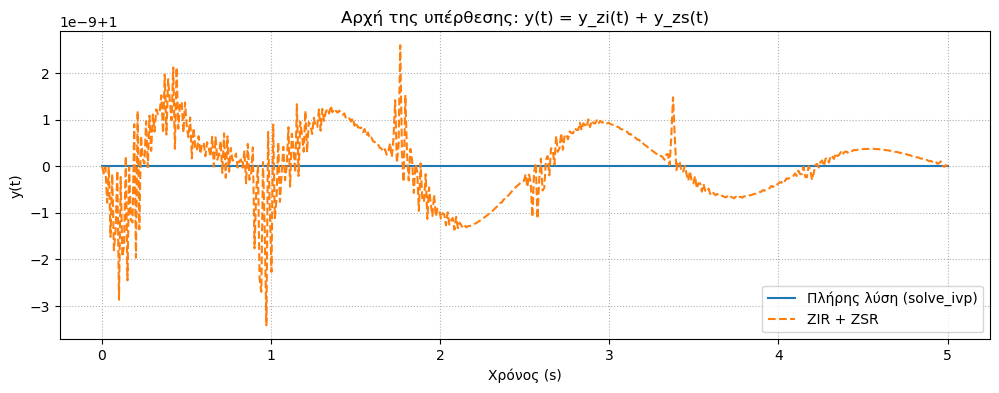

In [16]:
sol_tot = solve_ivp(rhs, t_span=(0, 5), y0=[1.0, 0.0],
                    args=(lambda t: 1.0,),   # ΚΑΙ αρχικές συνθήκες ΚΑΙ είσοδος
                    method='RK45', t_eval=t, rtol=1e-8, atol=1e-10)
y_tot = sol_tot.y[0]

print('Μέγιστη διαφορά |y_total - (y_zir + y_zsr)| =',
      np.max(np.abs(y_tot - (y_zir + y_zsr))))

plt.figure(figsize=(12, 4))
plt.plot(t, y_tot,          '-',  label='Πλήρης λύση (solve_ivp)')
plt.plot(t, y_zir + y_zsr,  '--', label='ZIR + ZSR')
plt.grid(linestyle=':'); plt.legend(loc='lower right')
plt.title('Αρχή της υπέρθεσης: y(t) = y_zi(t) + y_zs(t)')
plt.xlabel('Χρόνος (s)'); plt.ylabel('y(t)'); plt.show()

Μη σας φαίνεται ότι υπάρχει πράγματι διαφορά! Δείτε τον κατακόρυφο άξονα - οι τιμές του είναι της ταξης του $10^{-9}$!

**Παρατηρήσεις:**

- Παλαιότερος (αλλά ακόμη πολύ διαδεδομένος) επιλύτης είναι η `scipy.integrate.odeint`. Η διαφορά στη σύνταξη είναι ότι περιμένει τη συνάρτηση ως `f(s, t)` (αντεστραμμένη σειρά ορισμάτων σε σχέση με τον `solve_ivp`, που θέλει `f(t, s)`). Δοκιμάστε την αν θέλετε.

- Οι παράμετροι `rtol`/`atol` ελέγχουν την **ανοχή σφάλματος (tolerance)**: μικρότερες τιμές → μικρότερο εσωτερικό βήμα → μεγαλύτερη ακρίβεια (αλλά περισσότερος υπολογισμός). Είναι το ανάλογο του «μικρού $T_s$», με τη διαφορά ότι εδώ ο επιλύτης το ρυθμίζει **προσαρμοστικά** μόνος του. Μπορείτε να παίξετε αν θέλετε με τις τιμές αυτές.

- Το `t_eval` καθορίζει μόνο **πού μας επιστρέφει** τη λύση (για να απεικονίσουμε τα γραφήματα) - δεν είναι το βήμα ολοκλήρωσης.

Με βάση τα παραπάνω γραφήματα: πόσο καλύτερη είναι η `solve_ivp` από τη μέθοδο Euler ($T_s=0.01$) και γιατί; Σημαίνει αυτό ότι δεν γίνεται πλέον καμία διακριτοποίηση; Γράψτε την απάντησή σας εδώ:

### Απάντηση:

Η `solve_ivp` (RK45) είναι **τάξεις μεγέθους** πιο ακριβής από τη μέθοδο Euler με $T_s=0.01$: στο γράφημα του σφάλματος, το σφάλμα της μεθόδου Euler είναι της τάξης του $10^{-2}$ ενώ της `solve_ivp` κοντά στην ανοχή που ζητήσαμε ($\sim 10^{-8}$). Ο λόγος είναι διπλός: (i) η Runge–Kutta 4ης/5ης τάξης έχει πολύ μικρότερο σφάλμα ανά βήμα από τη μέθοδο Euler 1ης τάξης, και (ii) το βήμα είναι **προσαρμοστικό** -- ο επιλύτης "πυκνώνει" τα βήματα εκεί που η λύση αλλάζει γρήγορα και τα "αραιώνει" όταν η λύση είναι ομαλή.

**Όχι**, δεν καταργείται η διακριτοποίηση: ο υπολογιστής δεν μπορεί να αναπαραστήσει τη συνεχή μεταβλητή $t$, οπότε η `solve_ivp` κάνει και αυτή αριθμητική ολοκλήρωση σε διακριτά (αλλά έξυπνα επιλεγμένα) βήματα. Αυτό που αλλάζει είναι ότι **δεν παράγουμε εμείς** τη διακριτή εξίσωση διαφορών με το χέρι, και ότι η υποκείμενη μέθοδος είναι πολύ ανώτερη της απλής μεθόδου Euler.

---
---